当前强制锁定的工作目录是: E:\03_Learning\MachineLearning\unet-pytorch


C:\Users\qq864\AppData\Local\Temp\ipykernel_43580\1719470426.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weight_path, map_lo

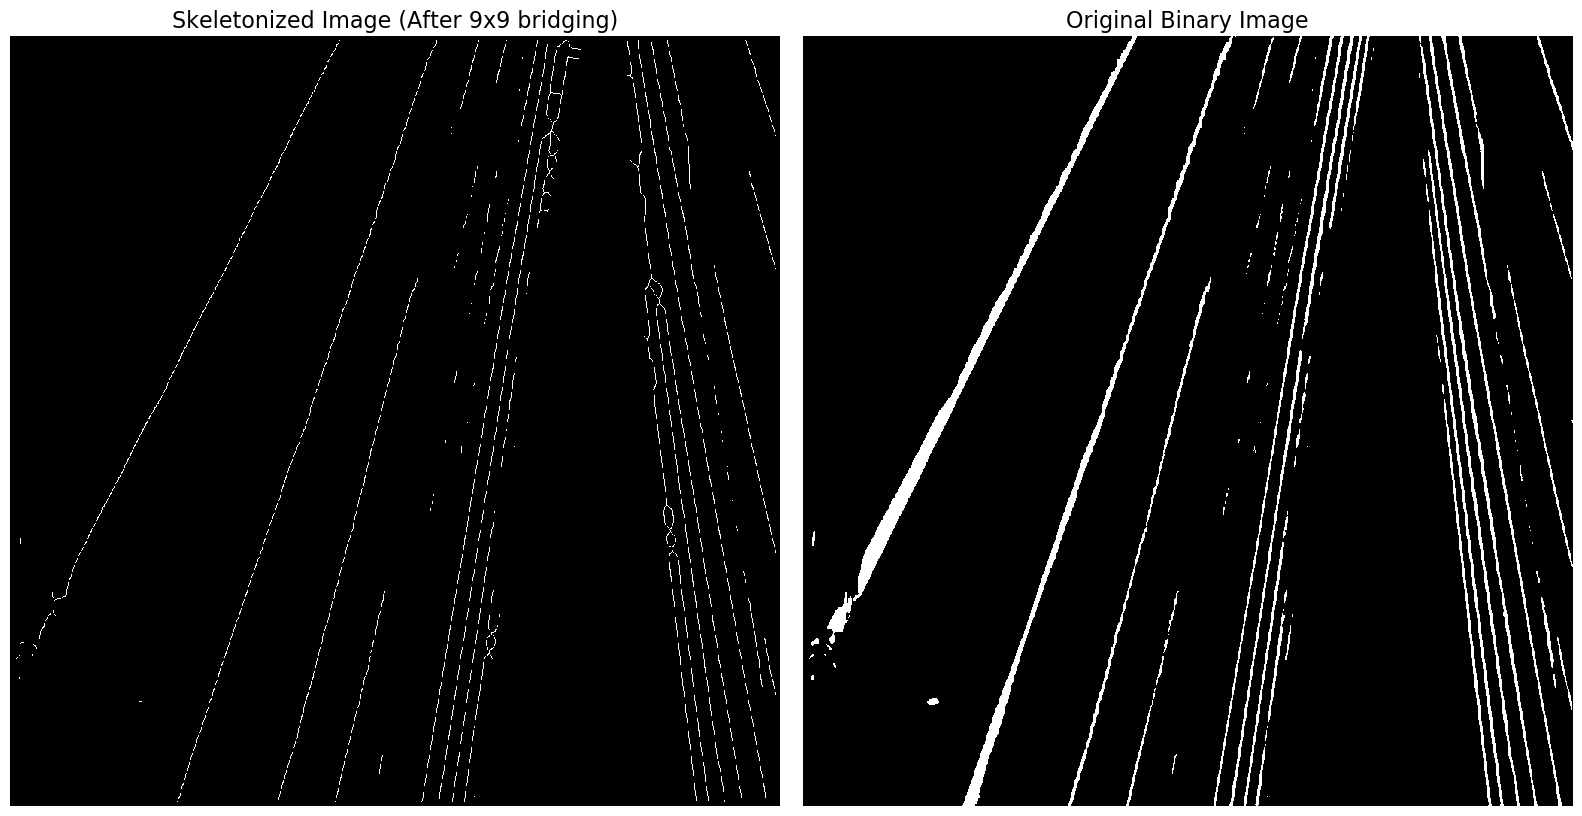

In [16]:
import numpy as np
import cv2
import sys
import os

# 🟢 1. 定义你项目的绝对根目录
project_root = r"E:\03_Learning\MachineLearning\unet-pytorch"

# 🟢 2. 强行将根目录加入 Python 的导包搜索路径中
if project_root not in sys.path:
    sys.path.append(project_root)

# 🟢 3. 顺便把当前运行目录也锁死在这个根目录下，防止后面读图片报错
os.chdir(project_root)
print("当前强制锁定的工作目录是:", os.getcwd())

pic_name = "0049_001"

# 🟢 4. 现在再导包，绝对不会报错了！
from nets.unet import Unet
import numpy as np
from numba import njit

@njit
def zhang_suen_thinning_fast(image):
    # 确保输入是 np.uint8 类型，并且只有 0 和 1
    # 使用 copy 避免修改原图
    img = image.copy()
    rows, cols = img.shape
    
    # 预分配 marker 数组，避免在循环中重复申请内存
    marker = np.zeros((rows, cols), dtype=np.uint8)
    
    while True:
        has_changed = False
        marker[:, :] = 0
        
        # 第一步：子迭代1
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if img[i, j] == 0:
                    continue
                
                # 直接获取 8 邻域，避免创建 list 和调用函数
                p2 = img[i-1, j]
                p3 = img[i-1, j+1]
                p4 = img[i, j+1]
                p5 = img[i+1, j+1]
                p6 = img[i+1, j]
                p7 = img[i+1, j-1]
                p8 = img[i, j-1]
                p9 = img[i-1, j-1]
                
                Np = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
                if Np < 2 or Np > 6:
                    continue
                
                # 计算 0到1 的跳变次数 (Ap)
                Ap = 0
                if p2 == 0 and p3 == 1: Ap += 1
                if p3 == 0 and p4 == 1: Ap += 1
                if p4 == 0 and p5 == 1: Ap += 1
                if p5 == 0 and p6 == 1: Ap += 1
                if p6 == 0 and p7 == 1: Ap += 1
                if p7 == 0 and p8 == 1: Ap += 1
                if p8 == 0 and p9 == 1: Ap += 1
                if p9 == 0 and p2 == 1: Ap += 1
                
                if Ap == 1 and (p2 * p4 * p6 == 0) and (p4 * p6 * p8 == 0):
                    marker[i, j] = 1
                    has_changed = True
                    
        # 直接在原图上减去 marker
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if marker[i, j] == 1:
                    img[i, j] = 0
                    
        marker[:, :] = 0
        
        # 第二步：子迭代2
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if img[i, j] == 0:
                    continue
                
                p2 = img[i-1, j]
                p3 = img[i-1, j+1]
                p4 = img[i, j+1]
                p5 = img[i+1, j+1]
                p6 = img[i+1, j]
                p7 = img[i+1, j-1]
                p8 = img[i, j-1]
                p9 = img[i-1, j-1]
                
                Np = p2 + p3 + p4 + p5 + p6 + p7 + p8 + p9
                if Np < 2 or Np > 6:
                    continue
                
                Ap = 0
                if p2 == 0 and p3 == 1: Ap += 1
                if p3 == 0 and p4 == 1: Ap += 1
                if p4 == 0 and p5 == 1: Ap += 1
                if p5 == 0 and p6 == 1: Ap += 1
                if p6 == 0 and p7 == 1: Ap += 1
                if p7 == 0 and p8 == 1: Ap += 1
                if p8 == 0 and p9 == 1: Ap += 1
                if p9 == 0 and p2 == 1: Ap += 1
                
                if Ap == 1 and (p2 * p4 * p8 == 0) and (p2 * p6 * p8 == 0):
                    marker[i, j] = 1
                    has_changed = True
                    
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if marker[i, j] == 1:
                    img[i, j] = 0
                    
        # 如果没有像素被删除，结束迭代
        if not has_changed:
            break
            
    return img

# 读取图像
import torch
from PIL import Image
import numpy as np

# ==========================================
# 替代原本的 cv2.imread，直接用模型推理原图
# ==========================================
model_weight_path = "miou_out/miou_unet_after/best_epoch_weights.pth" 
num_classes = 2 # 0背景, 1绳索
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Unet(num_classes=num_classes, backbone='vgg').to(device)
model.load_state_dict(torch.load(model_weight_path, map_location=device))
model.eval()
image_path = f"E:\\03_Learning\\MachineLearning\\unet-pytorch\\VOCdevkit\\VOC2007\\JPEGImages\\{pic_name}.jpg"

# 1. 读取原图并进行预处理 (与训练时保持一致)
raw_img = Image.open(image_path).convert('RGB')
img_np = np.array(raw_img, dtype=np.float32) / 255.0  # 归一化
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float()

# 放到 GPU 上
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
img_tensor = img_tensor.to(device)

# 2. 模型推理
with torch.no_grad():
    outputs = model(img_tensor)            # 假设你的模型变量名叫 model
    probs = torch.softmax(outputs, dim=1)  # 获取概率
    # 提取第 1 个通道 (绳索类) 的概率图，转回 CPU numpy 数组
    rope_prob_map = probs[0, 1, :, :].cpu().numpy() 

# 3. 得到二值化掩码 (0 和 1)
# 这一步就完全等同于你之前 cv2.threshold 得到的结果
binary = (rope_prob_map > 0.5).astype(np.uint8)

# (可选) 如果你需要 255 的灰度图形式：
img = binary * 255

# 🟢 修复1：将阈值设为 0。只要像素值 > 0（即等于1），就保留为 1
_, binary = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY)

# 🟢 修复1：将阈值设为 0。只要像素值 > 0（即等于1），就保留为 1
_, binary = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY)

# ==========================================
# 骨架提取与 9x9 卷积(闭运算)连接断点
# ==========================================
# 1. 第一次提取初始骨架
skeleton = zhang_suen_thinning_fast(binary)

# 2. 🟢 新增：使用 9x9 椭圆核进行闭运算，强行跨越并连接距离在 9 个像素以内的断点
kernel_9x9 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_9x9)

# 3. 🟢 新增：闭运算会把连接处变粗，所以我们必须再跑一次细化算法，把它削回 1 像素宽
skeleton = zhang_suen_thinning_fast(skeleton_closed)

# 4. 消除边缘干扰：将图片最外围的几个像素强制清零
border_size = 5  # 消除边缘 5 个像素的宽度
skeleton[:border_size, :] = 0       # 顶部清零
skeleton[-border_size:, :] = 0      # 底部清零
skeleton[:, :border_size] = 0       # 左侧清零
skeleton[:, -border_size:] = 0      # 右侧清零

# 强制转换回 uint8 格式，确保 OpenCV 正常渲染
skeleton_255 = (skeleton * 255).astype(np.uint8)

# ==========================================
# 可视化对比
# ==========================================
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.canvas.manager.set_window_title('Step 3: 最终智能寻路修复结果')

axes[0].imshow(skeleton_255, cmap='gray')
axes[0].set_title('Skeletonized Image (After 9x9 bridging)', fontsize=16)
axes[0].axis('off')

axes[1].imshow(binary * 255, cmap='gray')
axes[1].set_title('Original Binary Image', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

📍 开始射线追踪可视化分析...
✅ 诊断完毕！成功连上 65 条，射空了 174 条。


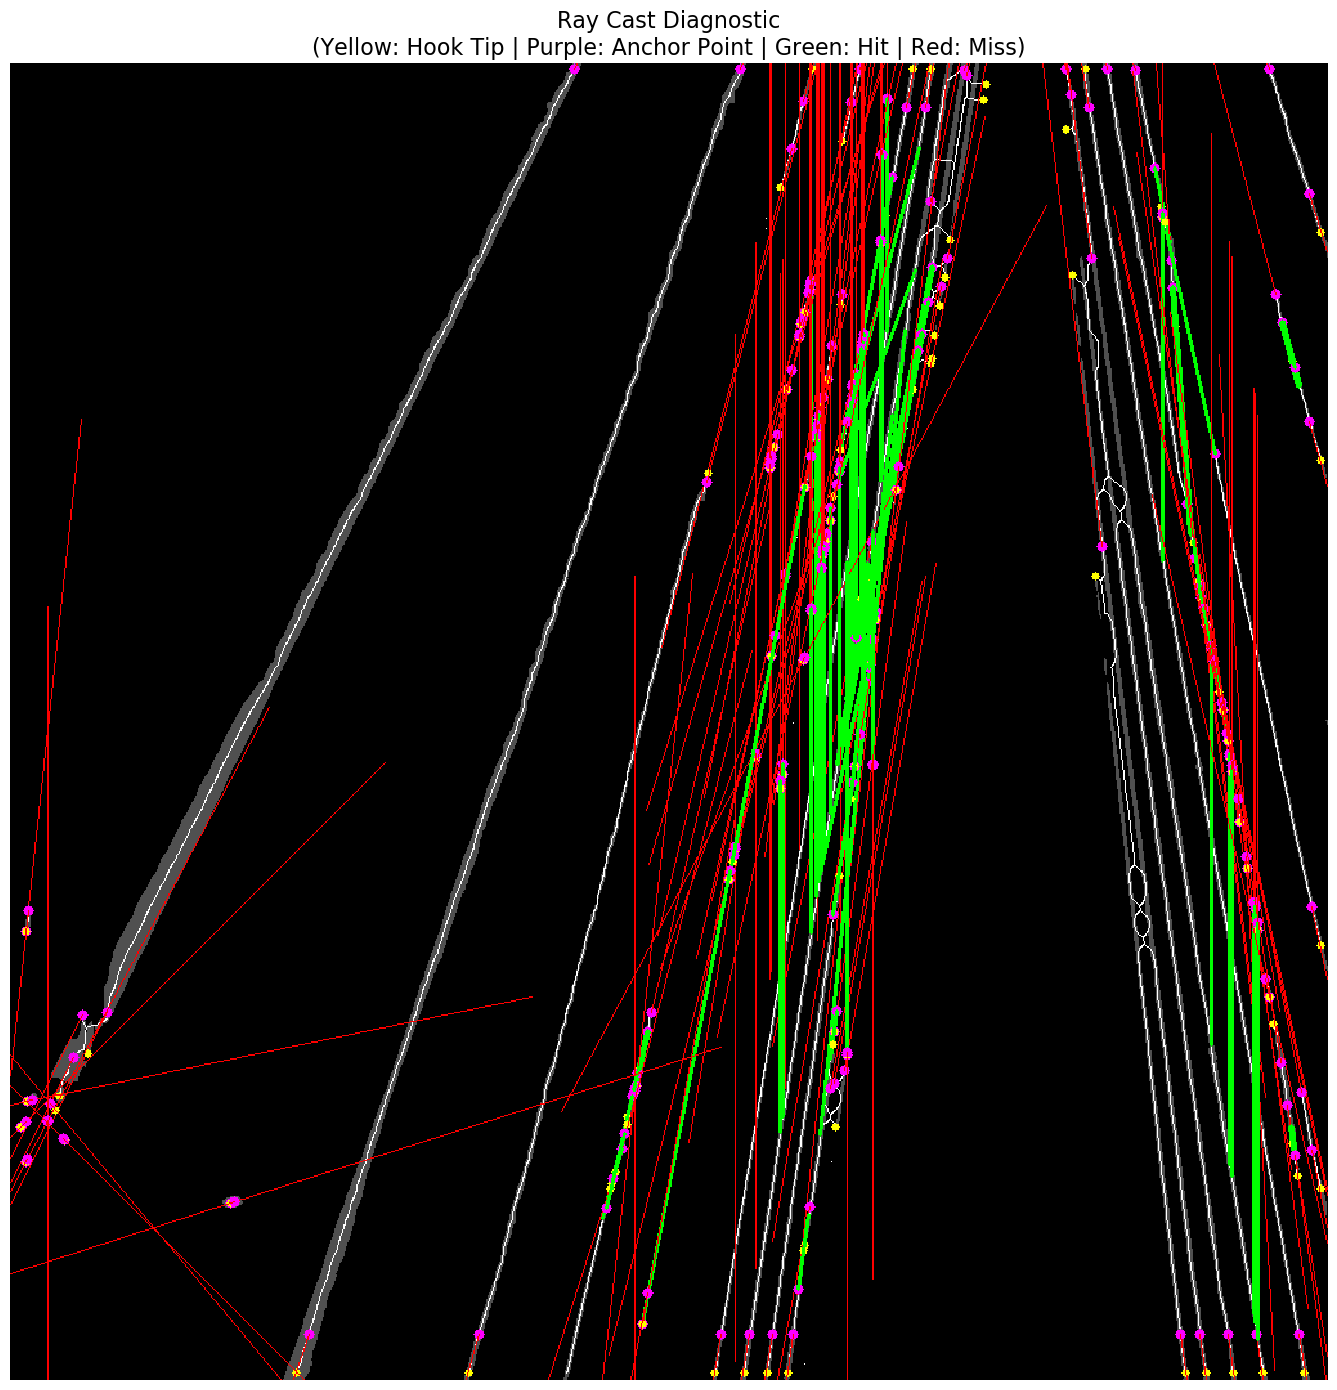

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import line

# ==========================================
# 辅助函数 1：提取单个连通域的端点
# ==========================================
def find_endpoints(skel_img):
    kernel = np.array([[1, 1, 1],
                       [1, 10, 1],
                       [1, 1, 1]], dtype=np.uint8)
    filtered = cv2.filter2D(skel_img, -1, kernel)
    endpoints_y, endpoints_x = np.where(filtered == 11)
    return list(zip(endpoints_y, endpoints_x))

# ==========================================
# 🟢 辅助函数 2：获取线段的【全局斜率】与【稳定锚点】
# ==========================================
def get_segment_features(comp_mask, dist_map, start_y, start_x, retreat_len=30):
    """
    计算全局斜率，并往回退缩 retreat_len 个像素寻找稳定锚点，避开末端倒钩。
    """
    ys, xs = np.where(comp_mask > 0)
    
    if len(xs) < 2:
        radius = dist_map[start_y, start_x]
        return (0.0, 0.0), max(1, int(np.round(radius * 2))), (start_y, start_x)

    pts = np.column_stack((xs, ys)).astype(np.float32)
    [vx, vy, cx, cy] = cv2.fitLine(pts, cv2.DIST_L2, 0, 0.01, 0.01)
    global_vec = np.array([vy[0], vx[0]]) 
    
    centroid_y, centroid_x = np.mean(ys), np.mean(xs)
    outward_approx = np.array([start_y - centroid_y, start_x - centroid_x])
    if np.dot(global_vec, outward_approx) < 0:
        global_vec = -global_vec
        
    # 🟢 核心改动：顺着骨架往回走，寻找避开倒钩的“稳定锚点”
    curr_y, curr_x = start_y, start_x
    prev_y, prev_x = -1, -1
    offsets = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    
    for _ in range(retreat_len):
        found_next = False
        for dy, dx in offsets:
            ny, nx = curr_y + dy, curr_x + dx
            if 0 <= ny < comp_mask.shape[0] and 0 <= nx < comp_mask.shape[1]:
                if comp_mask[ny, nx] > 0 and (ny != prev_y or nx != prev_x):
                    prev_y, prev_x = curr_y, curr_x
                    curr_y, curr_x = ny, nx
                    found_next = True
                    break 
        if not found_next:
            break 
            
    anchor_y, anchor_x = curr_y, curr_x
    
    # 获取锚点处的粗细（倒钩尖端往往偏细，锚点处更代表主干真实粗细）
    radius = dist_map[anchor_y, anchor_x]
    thickness = max(1, int(np.round(radius * 2)))
    
    norm = np.hypot(global_vec[0], global_vec[1])
    final_vec = (0.0, 0.0) if norm == 0 else (global_vec[0] / norm, global_vec[1] / norm)
    
    # 返回：方向向量，粗细，锚点坐标
    return final_vec, thickness, (anchor_y, anchor_x)

# ==========================================
# 核心函数：射线探测延伸修复 (从锚点发射)
# ==========================================
def ray_cast_healing(binary_mask, skeleton, max_ext_len=100, hit_threshold=10):
    print("📍 正在生成距离变换图与划分连通域...")
    binary_255 = (binary_mask > 0).astype(np.uint8) * 255
    dist_map = cv2.distanceTransform(binary_255, cv2.DIST_L2, 5)
    
    skel_8u = (skeleton > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(skel_8u, connectivity=8)
    
    healed_mask = binary_255.copy()
    success_count = 0
    
    for label_id in range(1, num_labels):
        comp_mask = (labels == label_id).astype(np.uint8)
        endpoints = find_endpoints(comp_mask)
        
        for (ey, ex) in endpoints:
            # 🟢 获取锚点坐标
            vec, thickness, anchor_pt = get_segment_features(comp_mask, dist_map, ey, ex)
            if vec == (0.0, 0.0):
                continue
                
            dir_y, dir_x = vec
            ay, ax = anchor_pt # 从锚点开始计算射线
            
            end_y = int(np.round(ay + dir_y * max_ext_len))
            end_x = int(np.round(ax + dir_x * max_ext_len))
            
            rect = (0, 0, labels.shape[1], labels.shape[0])
            is_inside, pt1, pt2 = cv2.clipLine(rect, (ax, ay), (end_x, end_y))
            if not is_inside:
                continue
                
            rr, cc = line(pt1[1], pt1[0], pt2[1], pt2[0])
            
            hits = 0
            target_point = None
            
            for r, c in zip(rr, cc):
                if r == ay and c == ax:
                    continue 
                    
                encountered_label = labels[r, c]
                if encountered_label > 0 and encountered_label != label_id:
                    hits += 1
                    if hits >= hit_threshold:
                        target_point = (r, c)
                        break 
                        
            if target_point is not None:
                # 🟢 将锚点与命中点连接，直接覆盖掉倒钩区域
                cv2.line(healed_mask, (ax, ay), (target_point[1], target_point[0]), 
                         color=255, thickness=thickness)
                success_count += 1
                
    print(f"✅ 射线探测完毕！共触发了 {success_count} 次成功延伸。")
    return healed_mask

# ==========================================
# 调试函数：全射线可视化分析 (Ray Cast Debugger)
# ==========================================
def visualize_all_rays(binary_mask, skeleton, max_ext_len=100, hit_threshold=10):
    print("📍 开始射线追踪可视化分析...")
    binary_255 = (binary_mask > 0).astype(np.uint8) * 255
    dist_map = cv2.distanceTransform(binary_255, cv2.DIST_L2, 5)
    
    skel_8u = (skeleton > 0).astype(np.uint8)
    num_labels, labels = cv2.connectedComponents(skel_8u, connectivity=8)
    
    h, w = binary_mask.shape
    debug_canvas = np.zeros((h, w, 3), dtype=np.uint8)
    
    debug_canvas[binary_mask > 0] = [80, 80, 80]     
    debug_canvas[skeleton > 0] = [255, 255, 255]      
    
    success_count = 0
    failed_count = 0
    
    for label_id in range(1, num_labels):
        comp_mask = (labels == label_id).astype(np.uint8)
        endpoints = find_endpoints(comp_mask)
        
        for (ey, ex) in endpoints:
            # 🔴 原端点画黄色小圆
            cv2.circle(debug_canvas, (ex, ey), 3, (255, 255, 0), -1)
            
            vec, thickness, anchor_pt = get_segment_features(comp_mask, dist_map, ey, ex)
            if vec == (0.0, 0.0):
                continue
                
            dir_y, dir_x = vec
            ay, ax = anchor_pt
            
            # 🔴 锚点画显眼的紫色大圆点
            cv2.circle(debug_canvas, (ax, ay), 4, (255, 0, 255), -1)
            
            end_y = int(np.round(ay + dir_y * max_ext_len))
            end_x = int(np.round(ax + dir_x * max_ext_len))
            
            rect = (0, 0, w, h)
            is_inside, pt1, pt2 = cv2.clipLine(rect, (ax, ay), (end_x, end_y))
            if not is_inside:
                continue
                
            rr, cc = line(pt1[1], pt1[0], pt2[1], pt2[0])
            hits = 0
            target_point = None
            
            for r, c in zip(rr, cc):
                if r == ay and c == ax:
                    continue 
                    
                encountered_label = labels[r, c]
                if encountered_label > 0 and encountered_label != label_id:
                    hits += 1
                    if hits >= hit_threshold:
                        target_point = (r, c)
                        break
                        
            if target_point is not None:
                # 命中：从紫点画绿线
                cv2.line(debug_canvas, (ax, ay), (target_point[1], target_point[0]), 
                         color=(0, 255, 0), thickness=thickness)
                success_count += 1
            else:
                # 未命中：从紫点画红线
                cv2.line(debug_canvas, (ax, ay), (pt2[0], pt2[1]), 
                         color=(255, 0, 0), thickness=1)
                failed_count += 1
                
    print(f"✅ 诊断完毕！成功连上 {success_count} 条，射空了 {failed_count} 条。")
    return debug_canvas

# 运行诊断并展示
debug_img = visualize_all_rays(binary, skeleton, max_ext_len=400)

fig, ax = plt.subplots(figsize=(14, 14))
ax.imshow(debug_img)
ax.set_title('Ray Cast Diagnostic\n(Yellow: Hook Tip | Purple: Anchor Point | Green: Hit | Red: Miss)', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
import cv2
import numpy as np

# ==========================================
# 辅助函数：计算 IoU (交并比)
# ==========================================
def calculate_iou(pred_mask, gt_mask):
    """
    计算预测掩码和真实掩码的 IoU。
    输入可以是 0/255 的 uint8 图，也可以是 bool 数组。
    """
    # 统一转换为布尔型，方便进行逻辑运算
    pred_bool = (pred_mask > 0)
    
    # 注意：VOC 数据集中，边缘/忽略区域的像素值通常是 255
    # 如果你的 GT 只有目标(如1或255)和背景(0)，用 gt_mask > 0 即可。
    # 这里我们严格一点，排除了 255 这个 ignore label（如果存在的话）
    # 如果你的 GT 里白色(255)就是目标，请把 `& (gt_mask != 255)` 删掉
    gt_bool = (gt_mask > 0) & (gt_mask != 255) if np.max(gt_mask) == 255 and np.mean(gt_mask==255) < 0.1 else (gt_mask > 0)

    # 确保两者尺寸一致
    if pred_bool.shape != gt_bool.shape:
        raise ValueError(f"尺寸不匹配！预测图: {pred_bool.shape}, GT图: {gt_bool.shape}")

    # 计算交集 (Intersection) 和并集 (Union)
    intersection = np.logical_and(pred_bool, gt_bool).sum()
    union = np.logical_or(pred_bool, gt_bool).sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0
        
    return intersection / union

# ==========================================
# 执行 IoU 对比分析
# ==========================================
# 1. 读取 Ground Truth 图像
gt_path = f"VOCdevkit\\VOC2007\\SegmentationClass\\{pic_name}.png"
gt_img = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)

if gt_img is None:
    print(f"❌ 找不到 GT 文件，请检查路径是否正确：{gt_path}")
else:
    print("📍 正在计算量化指标 (IoU)...")
    
    # 2. 准备需要对比的两张图
    # binary 是你最初始的断裂掩码
    # healed_mask 是缝合后的掩码 (如果你之前没存下来，这里再跑一次)
    healed_mask = ray_cast_healing(binary, skeleton, max_ext_len=400)
    
    # 3. 计算 IoU
    iou_before = calculate_iou(binary, gt_img)
    iou_after = calculate_iou(healed_mask, gt_img)
    
    # 4. 打印结果
    print("-" * 30)
    print(f"📊 处理前 IoU (Before): {iou_before:.4f}")
    print(f"📊 处理后 IoU (After) : {iou_after:.4f}")
    
    improvement = (iou_after - iou_before) * 100
    if improvement > 0:
        print(f"🎉 修复成功！IoU 提升了 {improvement:.2f}%")
    elif improvement == 0:
        print("⚖️ IoU 无变化。")
    else:
        print(f"⚠️ 警告：IoU 下降了 {abs(improvement):.2f}%，可能是射线过度延伸造成了假阳性 (False Positives)。")
    print("-" * 30)

📍 正在计算量化指标 (IoU)...
📍 正在生成距离变换图与划分连通域...
✅ 射线探测完毕！共触发了 135 次成功延伸。
------------------------------
📊 处理前 IoU (Before): 0.3918
📊 处理后 IoU (After) : 0.3498
⚠️ 警告：IoU 下降了 4.20%，可能是射线过度延伸造成了假阳性 (False Positives)。
------------------------------


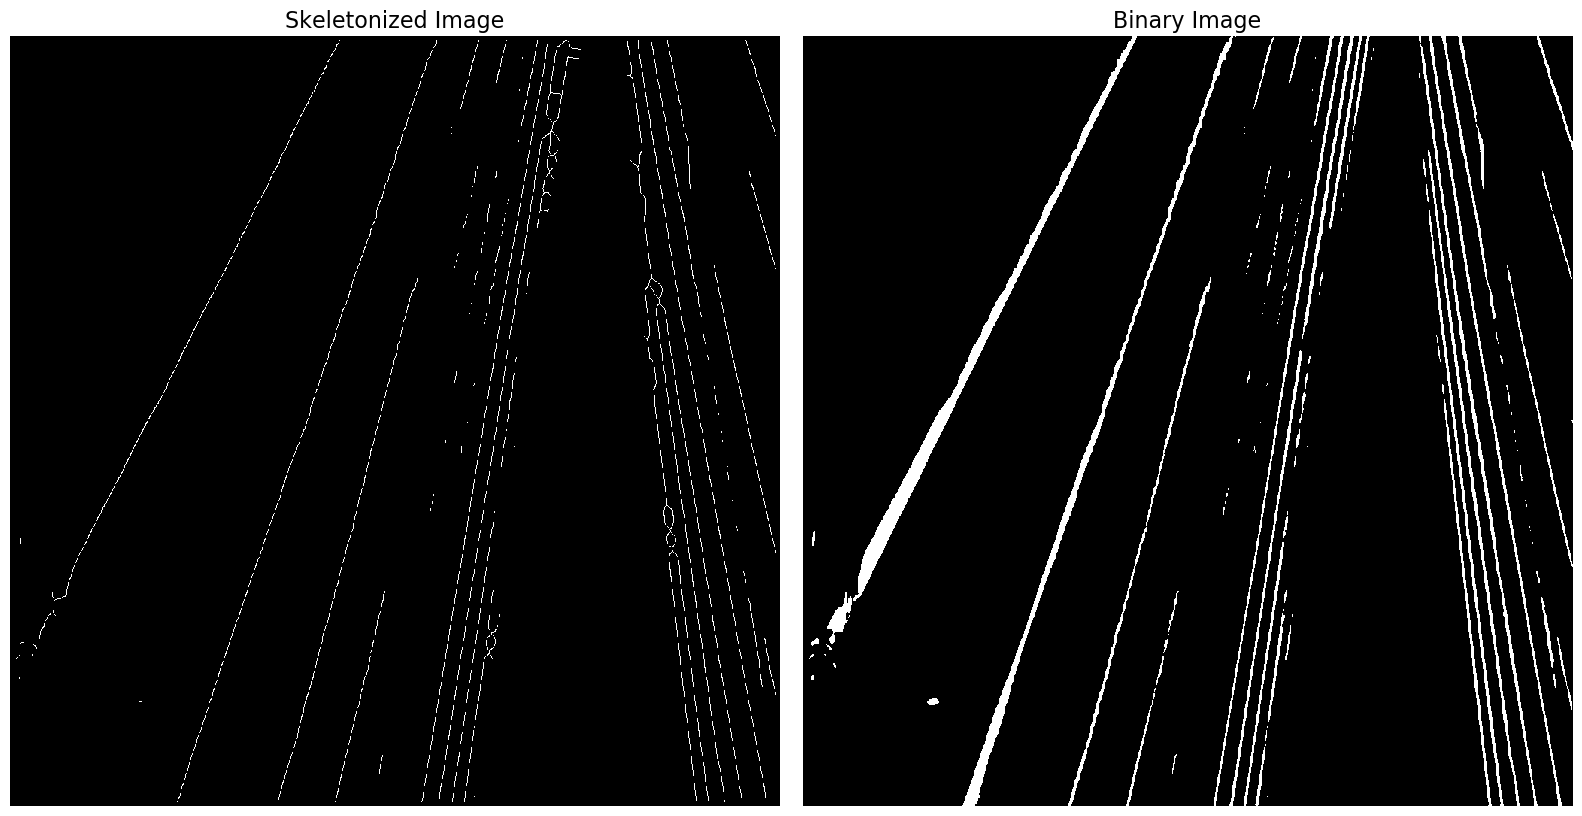

In [19]:
    
# 🟢 消除边缘干扰：将图片最外围的几个像素强制清零
border_size = 5  # 消除边缘 5 个像素的宽度，你可以根据实际情况调整
skeleton[:border_size, :] = 0       # 顶部清零
skeleton[-border_size:, :] = 0      # 底部清零
skeleton[:, :border_size] = 0       # 左侧清零
skeleton[:, -border_size:] = 0      # 右侧清零

# 🟢 修复2：强制转换回 uint8 格式，确保 OpenCV 正常渲染
skeleton_255 = (skeleton * 255).astype(np.uint8)
# 可视化对比
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.canvas.manager.set_window_title('Step 3: 最终智能寻路修复结果')

axes[0].imshow(skeleton_255, cmap='gray')
axes[0].set_title('Skeletonized Image', fontsize=16)
axes[0].axis('off')

axes[1].imshow(binary * 255, cmap='gray')
axes[1].set_title('Binary Image', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

✅ 概率图提取成功！
🗺️ 正在生成寻路地形代价图...


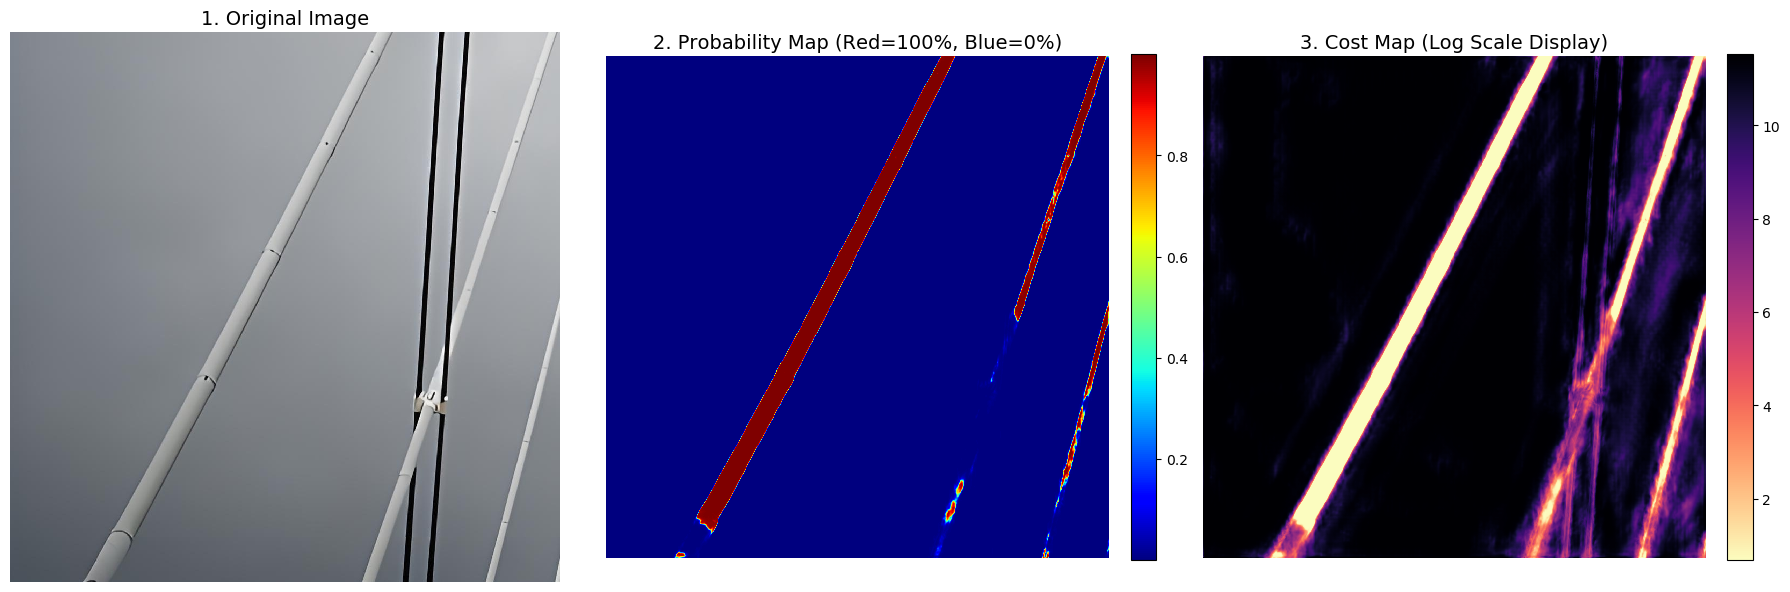

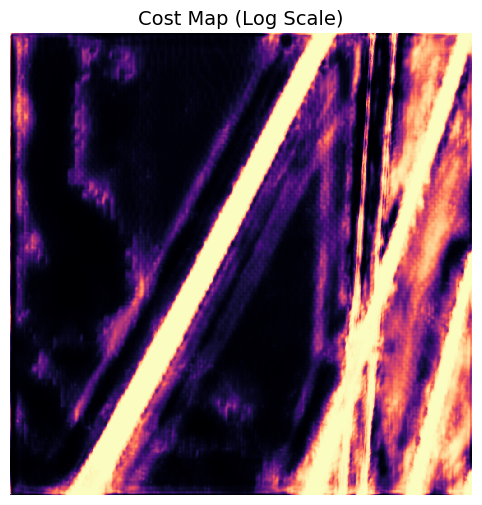

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

def preprocess_image(img_path):
    """读取并预处理图像 (确保与训练时的预处理一致)"""
    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img, dtype=np.float32)
    # 假设你使用的是 0-1 归一化
    img_np = img_np / 255.0
    # 转为 [1, C, H, W]
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float()
    return img, img_tensor

def generate_cost_map():
    # ==========================================
    # 1. 路径与配置 (请核对路径是否准确)
    # ==========================================
    test_image_path = f"VOCdevkit/VOC2007/JPEGImages/{pic_name}.jpg" 
    
    orig_img, img_tensor = preprocess_image(test_image_path)
    img_tensor = img_tensor.to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1) 
        # 提取绳索通道的概率图: 形状 (H, W)
        rope_prob_map = probs[0, 1, :, :].cpu().numpy() 

    print("✅ 概率图提取成功！")

    # ==========================================
    # 3. 核心算法：将概率图转换为“地形代价图” (Cost Map)
    # ==========================================
    print("🗺️ 正在生成寻路地形代价图...")
    epsilon = 1e-5
    # 概率越高，代价越小；概率越低，代价呈指数级放大
    cost_map = 1.0 / (rope_prob_map + epsilon)
    
    # 限制一下最大代价，防止无穷大导致寻路算法溢出 (比如封顶在 100000)
    max_cost = 100000.0
    cost_map = np.clip(cost_map, 0, max_cost)

    # ==========================================
    # 4. 可视化 (概率图 vs 代价图)
    # ==========================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.canvas.manager.set_window_title('Step 2: 概率图与地形代价图')

    # 左图：原始图像
    axes[0].imshow(orig_img)
    axes[0].set_title('1. Original Image', fontsize=14)
    axes[0].axis('off')

    # 中图：概率图 (Heatmap)
    # 使用 jet 伪彩色，红色代表概率高(1)，蓝色代表概率低(0)
    im1 = axes[1].imshow(rope_prob_map, cmap='jet')
    axes[1].set_title('2. Probability Map (Red=100%, Blue=0%)', fontsize=14)
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # 右图：代价图 (Cost Map)
    # 💡 视觉小技巧：因为代价图的数值跨度太大(1 到 100000)，直接画会一片黑。
    # 所以我们用 np.log1p (对数) 来压缩显示范围，让肉眼能看出层级，但底层的 cost_map 数值是不变的！
    cost_map_visual = np.log1p(cost_map) 
    im2 = axes[2].imshow(cost_map_visual, cmap='magma_r') # 反向岩浆色：亮处代表好走，暗处代表难走
    axes[2].set_title('3. Cost Map (Log Scale Display)', fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    return rope_prob_map, cost_map

# 运行并保存这两个核心矩阵供下一步使用
rope_prob_map, cost_map = generate_cost_map()

📍 正在生成距离变换图与扫描断裂端点...
🎯 共发现 20 个端点！
端点数据：[((-0.9701425001453319, 0.24253562503633297), 24), ((-0.9486832980505138, 0.31622776601683794), 15), ((-0.9805806756909201, 0.19611613513818402), 12), ((0.9977851578566089, -0.06651901052377393), 15), ((0.9486832980505138, -0.31622776601683794), 6), ((-0.9912279006826347, 0.13216372009101796), 7), ((0.9974586998307351, 0.07124704998790965), 10), ((0.0, 0.0), 6), ((0.9662349396012463, -0.25766265056033233), 6), ((0.9486832980505138, -0.31622776601683794), 7), ((-0.9701425001453319, 0.24253562503633297), 4), ((-0.9912279006826347, 0.13216372009101796), 9), ((0.9701425001453319, -0.24253562503633297), 2), ((-0.9701425001453319, 0.24253562503633297), 2), ((0.9701425001453319, -0.24253562503633297), 2), ((0.9333456062030595, -0.3589790793088691), 12), ((0.8682431421244593, -0.49613893835683387), 12), ((1.0, 0.0), 20), ((-0.9958932064677039, -0.09053574604251853), 1), ((0.9958932064677039, 0.09053574604251853), 4)]


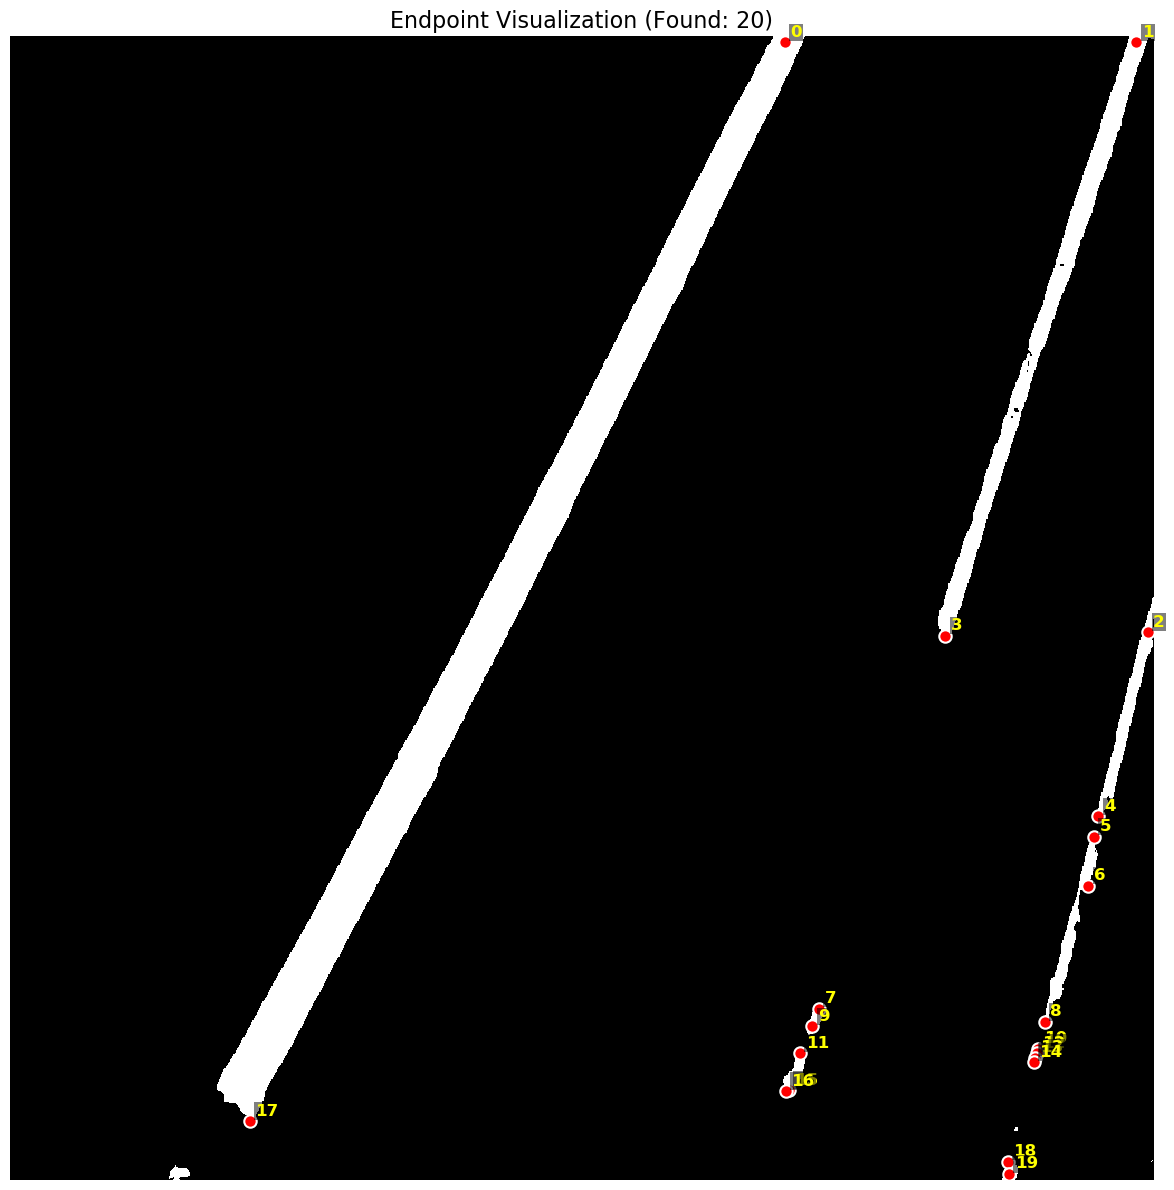

📐 带有角度约束(2°)及动态宽度的探测启动中...
Debug: Checking endpoints 3 and 9
  - Point A: (536, 837), Vector A: (0.9977851578566089, -0.06651901052377393), Thickness A: 15
  - Point B: (886, 718), Vector B: (0.9486832980505138, -0.31622776601683794), Thickness B: 7
  - Distance: 369.67688594230503
✅ 严格校验完成！成功缝合了 2 处断裂。


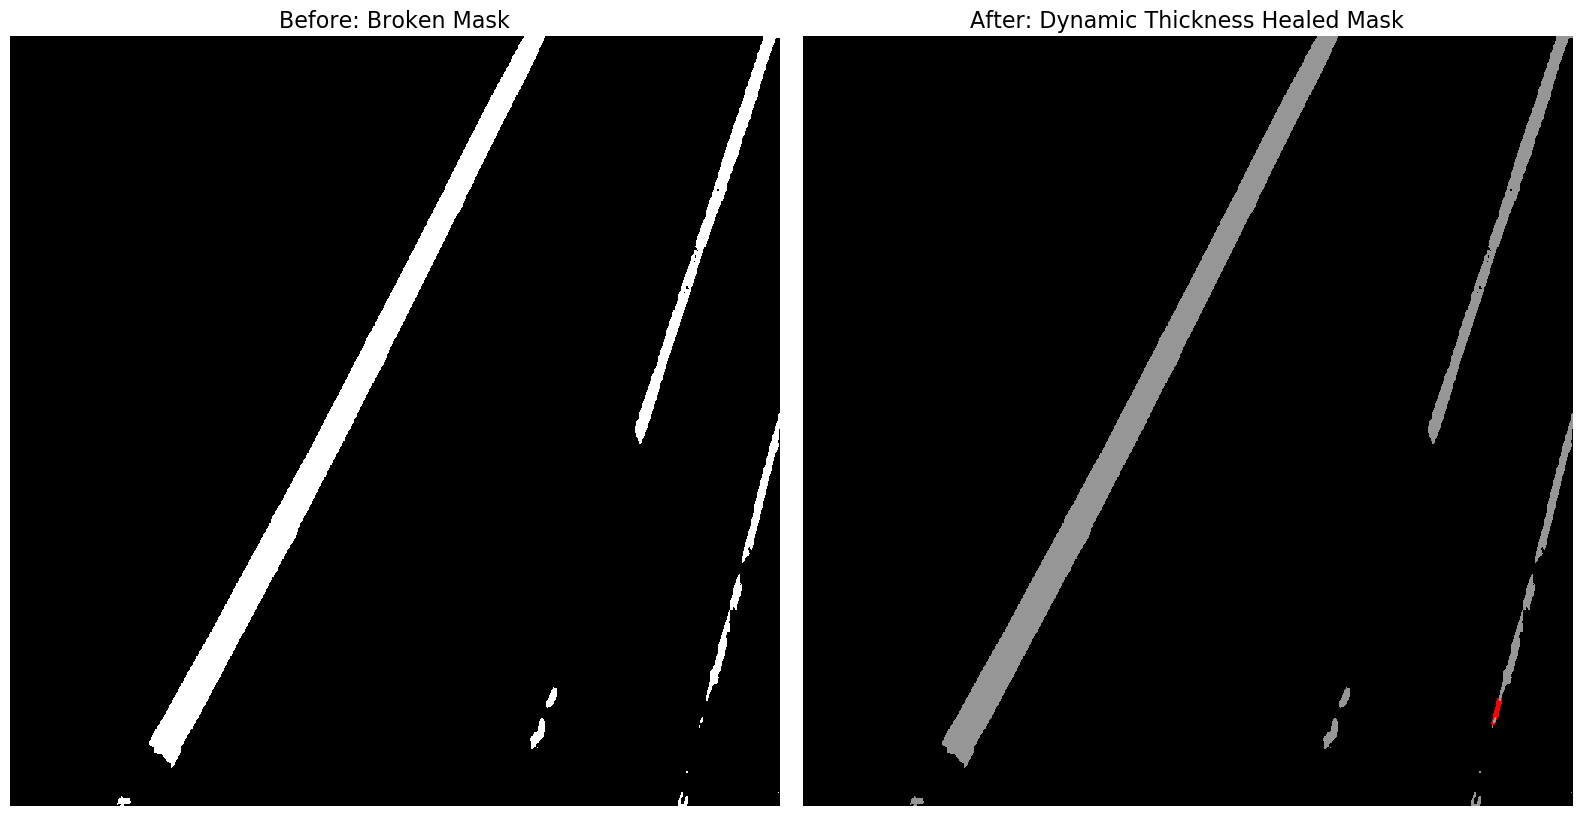

True

In [121]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import line

# ==========================================
# 辅助函数 1：利用卷积找出所有骨架端点
# ==========================================
def find_endpoints(skeleton):
    skel_img = (skeleton > 0).astype(np.uint8)
    kernel = np.array([[1, 1, 1],
                       [1, 10, 1],
                       [1, 1, 1]], dtype=np.uint8)
    filtered = cv2.filter2D(skel_img, -1, kernel)
    endpoints_y, endpoints_x = np.where(filtered == 11)
    return list(zip(endpoints_y, endpoints_x))

# ==========================================
# 🟢 辅助函数 2：计算端点的“延伸向量”与“动态粗细”
# ==========================================
def get_outward_vector_and_thickness(skel_img, dist_map, start_y, start_x, trace_length=15):
    """
    顺着骨架往回走，不仅计算延伸方向，还利用 dist_map (距离变换图) 获取绳索厚度
    """
    curr_y, curr_x = start_y, start_x
    prev_y, prev_x = -1, -1
    
    offsets = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]
    
    for _ in range(trace_length):
        found_next = False
        for dy, dx in offsets:
            ny, nx = curr_y + dy, curr_x + dx
            if 0 <= ny < skel_img.shape[0] and 0 <= nx < skel_img.shape[1]:
                if skel_img[ny, nx] > 0 and (ny != prev_y or nx != prev_x):
                    prev_y, prev_x = curr_y, curr_x
                    curr_y, curr_x = ny, nx
                    found_next = True
                    break 
        if not found_next:
            break 
            
    vy = start_y - curr_y
    vx = start_x - curr_x
    norm = np.sqrt(vy**2 + vx**2)
    vec = (0.0, 0.0) if norm == 0 else (vy / norm, vx / norm)
    
    # 🟢 魔法所在：读取向内追溯点在距离变换图上的值（即该处的半径）
    # 半径 * 2 即为绳索厚度，确保最小厚度为 1
    radius = dist_map[curr_y, curr_x]
    thickness = max(1, int(np.round(radius * 2)))
    
    return vec, thickness

# ==========================================
# 核心寻路函数 (直线概率 + 角度校验 + 🟢动态粗细)
# ==========================================
def smart_pathfinding_straight(binary_mask, skeleton, rope_prob_map, 
                               max_distance=300, min_avg_prob=0.02, 
                               max_angle_degree=30):
    """
    去掉了固定的 draw_thickness 参数，现为全自动动态适应！
    """
    print("📍 正在生成距离变换图与扫描断裂端点...")
    
    # 🟢 计算全图的距离变换，获取每个像素到边缘的距离
    # OpenCV 的 distanceTransform 需要输入 uint8 格式（0 和 255）
    binary_255 = (binary_mask > 0).astype(np.uint8) * 255
    dist_map = cv2.distanceTransform(binary_255, cv2.DIST_L2, 5)
    
    endpoints = find_endpoints(skeleton)
    skel_img = (skeleton > 0).astype(np.uint8)
    
    # 🟢 提取方向向量，并同时提取每个端点的动态厚度
    endpoint_data = [get_outward_vector_and_thickness(skel_img, dist_map, y, x, trace_length=15) for y, x in endpoints]
    
    print(f"🎯 共发现 {len(endpoints)} 个端点！")
    print(f"端点数据：{endpoint_data}")
    fig, ax = plt.subplots(figsize=(12, 12)) # 设置大一点，方便缩放查看像素细节
    fig.canvas.manager.set_window_title('调试：端点位置标注')
    
    # 假设你的原图背景比较暗，用 cmap='gray' 显示
    ax.imshow(binary, cmap='gray', interpolation='none')
    
    y_coords = [pt[0] for pt in endpoints]
    x_coords = [pt[1] for pt in endpoints]

    # 画出红色的端点
    ax.scatter(x_coords, y_coords, s=80, c='red', marker='o', edgecolors='white', linewidths=1.5, label='Endpoints')

    # 🟢 新增：遍历每个端点，并在图上打上下标 i
    for i, (y, x) in enumerate(endpoints):
        # x+5, y-5 是为了给文字加一点偏移量，防止数字直接挡住红点
        # color='yellow' 黄色在黑白灰背景上最醒目
        ax.text(x + 5, y - 5, str(i), color='yellow', fontsize=12, fontweight='bold', 
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1)) # 加个半透明黑底防看不清

    ax.set_title(f"Endpoint Visualization (Found: {len(endpoints)})", fontsize=16)
    ax.axis('off') # 隐藏坐标轴
    plt.tight_layout()
    plt.show()
    
    healed_mask = (binary_mask > 0).astype(np.uint8)
    if len(endpoints) < 2:
        return healed_mask
    
    print(f"📐 带有角度约束({max_angle_degree}°)及动态宽度的探测启动中...")
    successful_connections = 0
    min_cos_val = np.cos(np.radians(max_angle_degree))
    
    for i in range(len(endpoints)):
        for j in range(i + 1, len(endpoints)):
            ptA = endpoints[i]
            ptB = endpoints[j]
            
            vec_A, thick_A = endpoint_data[i]
            vec_B, thick_B = endpoint_data[j]
            
            dy = ptB[0] - ptA[0]
            dx = ptB[1] - ptA[1]
            dist = np.sqrt(dy**2 + dx**2)
            if i == 3 and j == 9:
                print(f"Debug: Checking endpoints {i} and {j}")
                print(f"  - Point A: {ptA}, Vector A: {vec_A}, Thickness A: {thick_A}")
                print(f"  - Point B: {ptB}, Vector B: {vec_B}, Thickness B: {thick_B}")
                print(f"  - Distance: {dist}")
            if dist > max_distance or dist == 0:
                continue
                
            dir_AB = (dy / dist, dx / dist)
            dir_BA = (-dy / dist, -dx / dist)
            
            dot_A = vec_A[0] * dir_AB[0] + vec_A[1] * dir_AB[1]
            dot_B = vec_B[0] * dir_BA[0] + vec_B[1] * dir_BA[1]
            
            if i == 3 and j == 9:
                print(f"  - Dot Product A: {dot_A}, Cos Threshold: {min_cos_val}")
                print(f"  - Dot Product B: {dot_B}, Cos Threshold: {min_cos_val}")
            if dot_A < min_cos_val or dot_B < min_cos_val:
                continue
                
            rr, cc = line(ptA[0], ptA[1], ptB[0], ptB[1])
            rr = np.clip(rr, 0, rope_prob_map.shape[0] - 1)
            cc = np.clip(cc, 0, rope_prob_map.shape[1] - 1)
            
            avg_prob = np.mean(rope_prob_map[rr, cc])
            
            if i == 3 and j == 9:
                print(f"  - Average Probability along line: {avg_prob}")
                print(f"  - Minimum Average Probability Threshold: {min_avg_prob}")
            if avg_prob < min_avg_prob:
                continue
                
            # 🟢 动态画笔宽度：取连接的两个端点粗细的平均值
            dynamic_thickness = max(1, int(np.round((thick_A + thick_B) / 2)))
            
            # 绘制自适应粗细的连接线
            cv2.line(healed_mask, (ptA[1], ptA[0]), (ptB[1], ptB[0]), 
                     color=1, thickness=dynamic_thickness)
            successful_connections += 1

    print(f"✅ 严格校验完成！成功缝合了 {successful_connections} 处断裂。")
    return healed_mask

# ==========================================
# 执行与可视化展示
# ==========================================
import matplotlib.pyplot as plt

healed_binary_mask = smart_pathfinding_straight(binary, skeleton, rope_prob_map, 
                                                max_distance=100, min_avg_prob=0.01,
                                                max_angle_degree=2)

# 可视化对比
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.canvas.manager.set_window_title('Step 3: 自适应宽度+方向约束的直线修复')

axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Before: Broken Mask', fontsize=16)
axes[0].axis('off')

diff_mask = healed_binary_mask - (binary > 0).astype(np.uint8)
show_img = np.zeros((binary.shape[0], binary.shape[1], 3), dtype=np.uint8)
temp_img = show_img.copy()
show_img[binary > 0] = [150, 150, 150]
show_img[diff_mask > 0] = [255, 0, 0]

axes[1].imshow(show_img)
axes[1].set_title('After: Dynamic Thickness Healed Mask', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

temp_img[diff_mask > 0] = [255, 255, 255]
temp_img[binary > 0] = [255, 255, 255]
temp_img = temp_img / 255.0
cv2.imwrite(f"test/{pic_name}.png", temp_img)


📊 单张图片 IoU 效果对比报告
【处理前 (U-Net 原始输出)】
  - 背景 (Class 0) IoU : 98.47%
  - 绳索 (Class 1) IoU : 73.40%
---------------------------------------------
【处理后 (直线概率寻路修复)】
  - 背景 (Class 0) IoU : 98.48%
  - 绳索 (Class 1) IoU : 73.56%
🎉 恭喜！直线修复成功，让这条绳索的 IoU 提升了 0.16%！


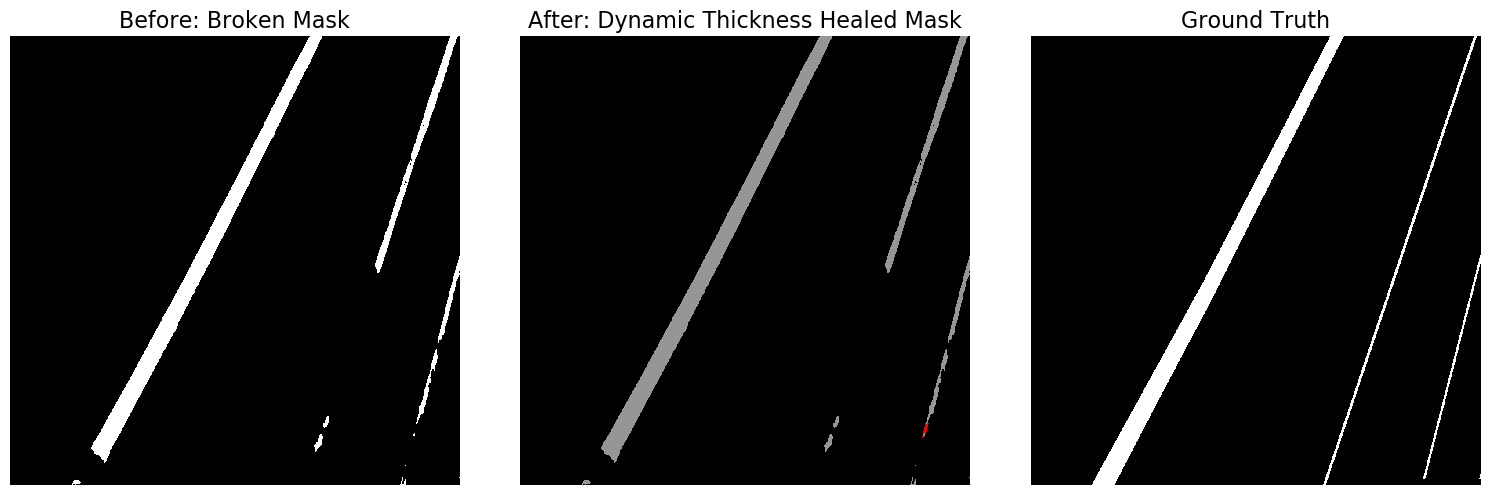

In [122]:
import cv2
import numpy as np

# ==========================================
# 辅助函数 1：计算混淆矩阵
# ==========================================
def fast_hist(a, b, n):
    """
    a: 真实标签 (Ground Truth)
    b: 预测结果 (Prediction)
    n: 类别数 (num_classes)
    """
    k = (a >= 0) & (a < n)
    return np.bincount(n * a[k].astype(int) + b[k].astype(int), minlength=n ** 2).reshape(n, n)

# ==========================================
# 辅助函数 2：计算每个类别的 IoU
# ==========================================
def per_class_iou(hist):
    """
    根据混淆矩阵计算 IoU (交并比)
    IoU = 真正例 / (真正例 + 假正例 + 假负例)
    """
    # np.maximum 防止分母为 0 导致报错
    ious = np.diag(hist) / np.maximum((hist.sum(1) + hist.sum(0) - np.diag(hist)), 1)
    return ious

# ==========================================
# 核心对比函数
# ==========================================
def evaluate_single_image_iou(gt_path, mask_before, mask_after, num_classes=2):
    """
    对比处理前后的掩码与 GT 的 IoU 变化
    """
    # 1. 读取真实标签图 (GT)
    gt_img = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    if gt_img is None:
        print(f"❌ 无法读取 GT 标签图，请检查路径: {gt_path}")
        return

    # 2. 统一格式：全部二值化为 0 和 1 的 uint8 矩阵
    gt_bin = (gt_img > 0).astype(np.uint8)
    mask_before = (mask_before > 0).astype(np.uint8)
    mask_after = (mask_after > 0).astype(np.uint8)

    # 3. 计算【处理前】的混淆矩阵和 IoU
    hist_before = fast_hist(gt_bin.flatten(), mask_before.flatten(), num_classes)
    iou_before = per_class_iou(hist_before)

    # 4. 计算【处理后】的混淆矩阵和 IoU
    hist_after = fast_hist(gt_bin.flatten(), mask_after.flatten(), num_classes)
    iou_after = per_class_iou(hist_after)

    # 5. 打印华丽的对比报告
    print("\n" + "="*45)
    print("📊 单张图片 IoU 效果对比报告")
    print("="*45)
    print("【处理前 (U-Net 原始输出)】")
    print(f"  - 背景 (Class 0) IoU : {iou_before[0]*100:.2f}%")
    print(f"  - 绳索 (Class 1) IoU : {iou_before[1]*100:.2f}%")
    print("-" * 45)
    print("【处理后 (直线概率寻路修复)】")
    print(f"  - 背景 (Class 0) IoU : {iou_after[0]*100:.2f}%")
    print(f"  - 绳索 (Class 1) IoU : {iou_after[1]*100:.2f}%")
    print("="*45)

    # 6. 结论判定
    diff = (iou_after[1] - iou_before[1]) * 100
    if diff > 0:
        print(f"🎉 恭喜！直线修复成功，让这条绳索的 IoU 提升了 {diff:.2f}%！")
    elif diff < 0:
        print(f"⚠️ 绳索 IoU 下降了 {abs(diff):.2f}%。")
        print("   原因可能是：连错了端点、或者画的直线太粗/太细，超出了真实绳索的范围。")
    else:
        print("⚖️ 平局：IoU 没有任何变化。")
        print("   原因可能是：代码没有找到合适的端点，或者被概率阈值拦截了，没画任何线。")
    # 可视化对比
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.canvas.manager.set_window_title('Step 3: 自适应宽度+方向约束的直线修复')

    axes[0].imshow(binary, cmap='gray')
    axes[0].set_title('Before: Broken Mask', fontsize=16)
    axes[0].axis('off')

    diff_mask = healed_binary_mask - (binary > 0).astype(np.uint8)
    show_img = np.zeros((binary.shape[0], binary.shape[1], 3), dtype=np.uint8)
    show_img[binary > 0] = [150, 150, 150]
    show_img[diff_mask > 0] = [255, 0, 0]

    axes[1].imshow(show_img)
    axes[1].set_title('After: Dynamic Thickness Healed Mask', fontsize=16)
    axes[1].axis('off')
    
    axes[2].imshow(gt_bin, cmap='gray')
    axes[2].set_title('Ground Truth', fontsize=16)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 执行测试
# ==========================================
# 假设你在上一个代码块中，处理前的变量叫 binary，处理后的变量叫 healed_binary_mask
if __name__ == "__main__":
    gt_path = f"VOCdevkit/VOC2007/SegmentationClass/{pic_name}.png"
    
    evaluate_single_image_iou(
        gt_path=gt_path, 
        mask_before=binary,               # 这是 U-Net 原始预测
        mask_after=healed_binary_mask,    # 这是加了直线的修复预测
        num_classes=2
    )